In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm
import cv2

In [36]:
ANNOTATIONS_CSV = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train_robo_1/_annotations.csv'
IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train_robo_1'
TEST_IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/test'

BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 0.001
NUM_CLASSES = 13
INPUT_SIZE = 224

CSV_PATH = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train.csv'

grid_size = 7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
def preprocess_image(image_path, mode="clahe"):
    img = cv2.imread(image_path)

    if mode == "clahe":
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        cl = clahe.apply(l)
        lab = cv2.merge((cl, a, b))
        enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(enhanced)

    elif mode == "canny":
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 100, 200)
        return Image.fromarray(edges)

    elif mode == "sobel":
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        sobel = cv2.magnitude(grad_x, grad_y)
        sobel = np.uint8(np.clip(sobel, 0, 255))
        return Image.fromarray(sobel)

    else:
        raise ValueError(f"Unknown mode {mode}")




In [ ]:
def detect_chocolate_bounding_boxes(image_path, show=True, max_boxes=20):
    # Load and preprocess image
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Edge detection (Canny)
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    # Morphological closing to reduce noise
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        aspect_ratio = w / h

        # Filter small boxes and extreme aspect ratios
        if area >= 1500 and 0.5 < aspect_ratio < 2.0:
            boxes.append((x, y, x + w, y + h))

    # Keep top N boxes by area
    boxes = sorted(boxes, key=lambda b: (b[2] - b[0]) * (b[3] - b[1]), reverse=True)[:max_boxes]

    if show:
        # Draw boxes
        image_with_boxes = image.copy()
        for (x1, y1, x2, y2) in boxes:
            cv2.rectangle(image_with_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)

        image_rgb = cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(7, 7))
        plt.imshow(image_rgb)
        plt.title(f"{len(boxes)} boxes detected")
        plt.axis('off')
        plt.show()

    return boxes

In [62]:
# Preprocessing
annotations = pd.read_csv(ANNOTATIONS_CSV)
class_names = sorted(annotations['class'].unique())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
annotations['class_idx'] = annotations['class'].map(class_to_idx)

train_ann, val_ann = train_test_split(annotations, test_size=0.2, stratify=annotations['class'], random_state=42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [63]:
class ChocolateDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, mode="clahe"):
        self.annotations = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.mode = mode

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        image_path = os.path.join(self.image_dir, row['filename'])
        image = preprocess_image(image_path, mode=self.mode)
        cropped = image.crop((row['xmin'], row['ymin'], row['xmax'], row['ymax']))
        if self.transform:
            cropped = self.transform(cropped)
        label = row['class_idx']
        return cropped, label


In [64]:
train_dataset = ChocolateDataset(train_ann, IMAGE_DIR, transform, mode="sobel")
val_dataset = ChocolateDataset(val_ann, IMAGE_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

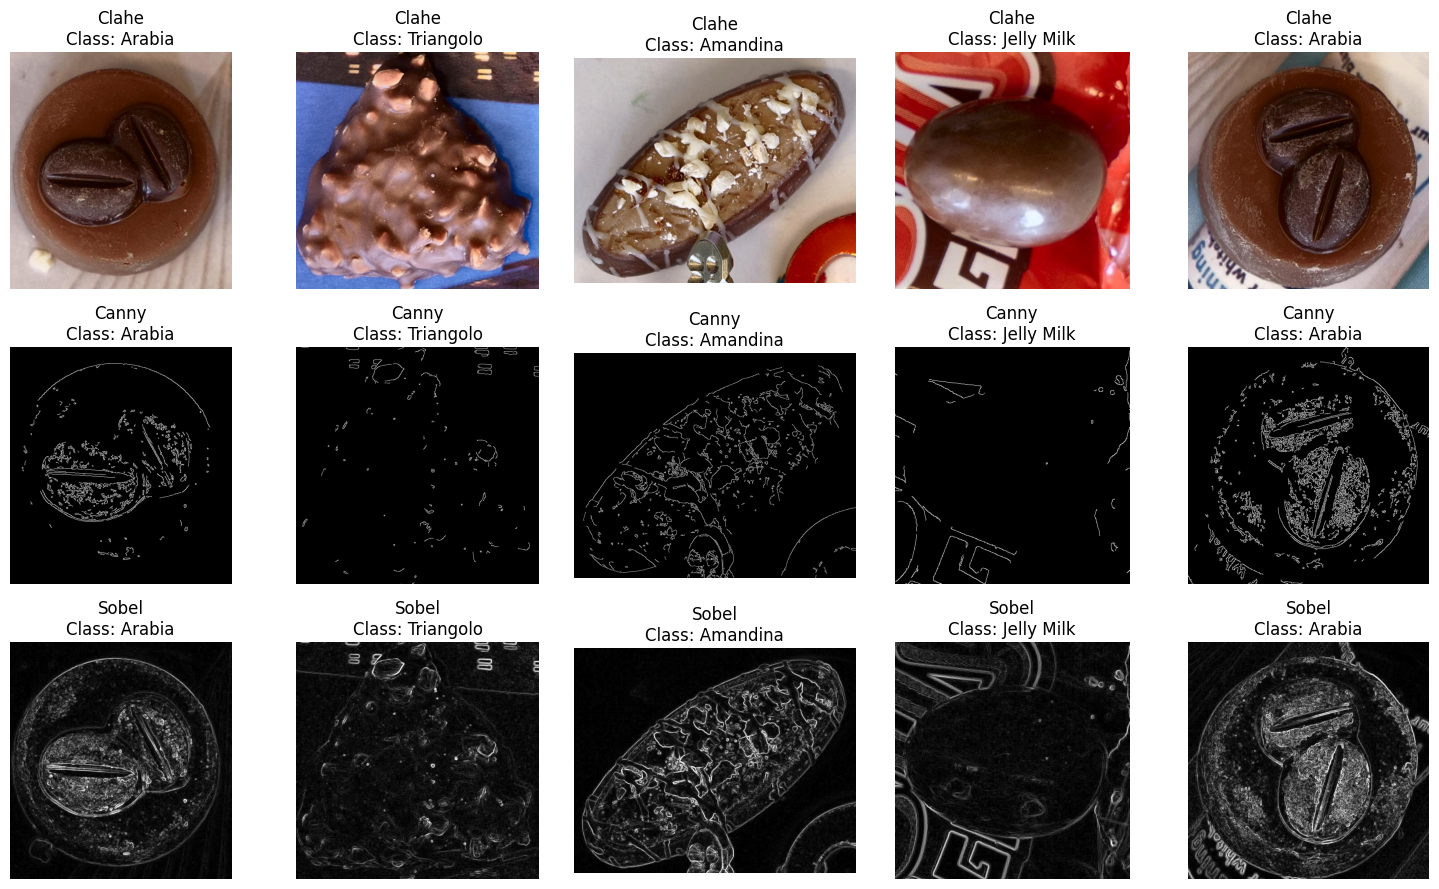

In [69]:
def show_preprocessed_samples_comparison(dataset, num_samples=5):
    modes = ["clahe", "canny", "sobel"]
    fig, axs = plt.subplots(len(modes), num_samples, figsize=(num_samples * 3, len(modes) * 3))
    for i in range(num_samples):
        row = dataset.annotations.iloc[i]
        image_path = os.path.join(dataset.image_dir, row['filename'])
        for j, mode in enumerate(modes):
            img = preprocess_image(image_path, mode=mode)
            cropped = img.crop((row['xmin'], row['ymin'], row['xmax'], row['ymax']))
            axs[j, i].imshow(cropped, cmap='gray' if mode != 'clahe' else None)
            axs[j, i].set_title(f"{mode.capitalize()}\nClass: {row['class']}")
            axs[j, i].axis('off')
    plt.tight_layout()
    plt.show()

show_preprocessed_samples_comparison(train_dataset)

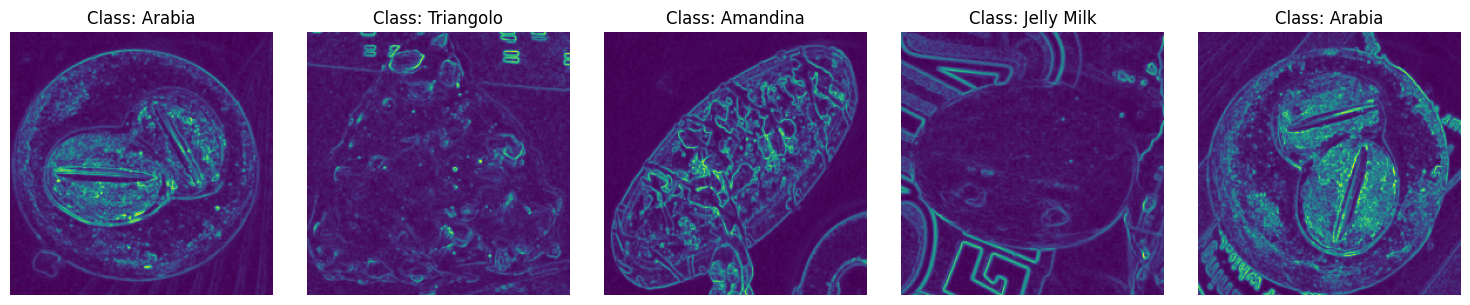

In [70]:
# === VISUALIZATION ===
def show_preprocessed_samples(dataset, num_samples=5):
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image_tensor, label = dataset[i]
        image_np = image_tensor.permute(1, 2, 0).numpy()
        plt.subplot(1, num_samples, i+1)
        plt.imshow(image_np)
        plt.title(f"Class: {class_names[label]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_preprocessed_samples(train_dataset)

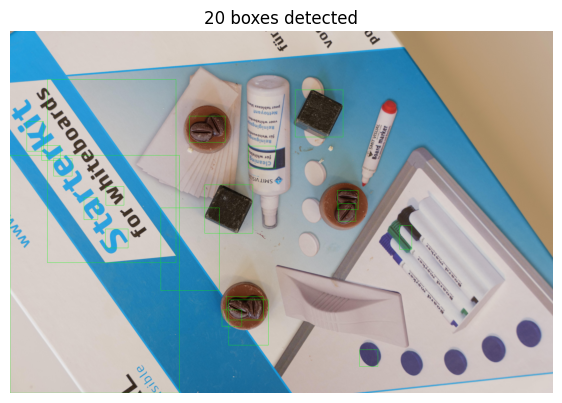

In [80]:
boxes = detect_chocolate_bounding_boxes(os.path.join(IMAGE_DIR, train_ann.iloc[0]['filename']), show=True)

In [42]:
# === TINY YOLO MODEL ===
class TinyYOLO(nn.Module):
    def __init__(self, S, C):
        super(TinyYOLO, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, stride=1, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear((INPUT_SIZE // 32)**2 * 256, 4096), nn.ReLU(),
            nn.Linear(4096, S * S * (5 + C))
        )
        self.S = S
        self.C = C

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x.view(-1, self.S, self.S, 5 + self.C)

model = TinyYOLO(S=grid_size, C=NUM_CLASSES).to(device)

In [43]:
# === LOSS ===
class YoloLoss(nn.Module):
    def __init__(self, lambda_coord=5, lambda_noobj=0.5):
        super(YoloLoss, self).__init__()
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, preds, targets):
        obj_mask = targets[..., 4] > 0
        noobj_mask = targets[..., 4] == 0

        coord_loss = self.lambda_coord * torch.sum(
            obj_mask.unsqueeze(-1) * (preds[..., 0:2] - targets[..., 0:2])**2
        )
        size_loss = self.lambda_coord * torch.sum(
            obj_mask.unsqueeze(-1) * (preds[..., 2:4] - targets[..., 2:4])**2
        )
        obj_loss = torch.sum((preds[..., 4] - targets[..., 4])**2 * obj_mask)
        noobj_loss = self.lambda_noobj * torch.sum((preds[..., 4] - targets[..., 4])**2 * noobj_mask)

        class_pred = preds[..., 5:5 + NUM_CLASSES]
        class_target = targets[..., 5:5 + NUM_CLASSES]

        if class_pred.shape[-1] != class_target.shape[-1]:
            raise RuntimeError(f"Mismatch in class prediction shape: got {class_pred.shape[-1]} but expected {class_target.shape[-1]}")

        class_mask = obj_mask.unsqueeze(-1).expand_as(class_target)
        class_loss = torch.sum(class_mask * (class_pred - class_target) ** 2)

        return coord_loss + size_loss + obj_loss + noobj_loss + class_loss

criterion = YoloLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [44]:
# === TRAINING LOOP ===
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)

    train_losses.append(train_loss / len(train_loader.dataset))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            loss = criterion(preds, labels)
            val_loss += loss.item() * imgs.size(0)

    val_losses.append(val_loss / len(val_loader.dataset))

    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

  0%|          | 0/30 [00:04<?, ?it/s]


RuntimeError: Mismatch in class prediction shape: got 13 but expected 11

In [ ]:
# === PLOT ===
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('YOLO Training and Validation Loss')
plt.grid(True)
plt.show()